In [10]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from preclean import preprocessing
import optuna
from sklearn.model_selection import train_test_split
from optuna.integration import XGBoostPruningCallback

/opt/anaconda3/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [6]:
# ── Uploading train ─────────────────────────────────
df_transac = pd.read_csv('data/train_transaction.csv')
df_id      = pd.read_csv('data/train_identity.csv')
df_train   = preprocessing(df_transac, df_id)

X = df_train.drop(columns=['TransactionID', 'isFraud'])
y = df_train['isFraud']

# ── Uploading test Kaggle ───────────────────────────
df_test_t  = pd.read_csv('data/test_transaction.csv')
df_test_i  = pd.read_csv('data/test_identity.csv')
df_test    = preprocessing(df_test_t, df_test_i)

X_test = df_test.drop(columns=['TransactionID'])

# Aligning columns (because of the get_dummies)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

 Final shape: (590540, 825)
  Residuals NaN (float) : 275762358
 Final shape: (506691, 463)
  Residuals NaN (float) : 90604215


Choice of parameters with Optuna

In [11]:
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.2, stratify=y, random_state=42
)
print(f"Échantillon : {len(X_sample)} lignes au lieu de {len(X)}")

Échantillon : 118108 lignes au lieu de 590540


In [ ]:
def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 9), #under 3 -> under fitting, above 9 -> over fitting
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True), #standard to be sure of the convergence
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0), #the number of data per tree
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20), #constraint on each tree
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # Fixed parameters
        'n_estimators':          300,
        'scale_pos_weight':      len(y[y==0]) / len(y[y==1]),
        'tree_method':           'hist',
        'eval_metric':           'auc',
        'early_stopping_rounds': 30,
        'random_state':          42,
        'n_jobs':                -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for idx_train, idx_val in skf.split(X_sample, y_sample):
        X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
        y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

        pruning_callback = XGBoostPruningCallback(trial, 'validation_0-auc')

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)



study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-06-20 19:29:26,209] A new study created in memory with name: no-name-f3f9e1c7-3a37-482c-9627-4d01b5c3de90


Best trial: 0. Best value: 0.93677:   5%|▌         | 1/20 [03:12<1:00:57, 192.52s/it]

[I 2026-06-20 19:32:38,734] Trial 0 finished with value: 0.9367698060496533 and parameters: {'max_depth': 7, 'learning_rate': 0.029280938336828866, 'subsample': 0.9801262567949518, 'colsample_bytree': 0.9136859648623827, 'min_child_weight': 14, 'reg_alpha': 0.009860942387603665, 'reg_lambda': 0.2872151568508661}. Best is trial 0 with value: 0.9367698060496533.


Best trial: 0. Best value: 0.93677:  10%|█         | 2/20 [06:41<1:00:44, 202.46s/it]

[I 2026-06-20 19:36:08,156] Trial 1 finished with value: 0.9164406916762498 and parameters: {'max_depth': 5, 'learning_rate': 0.013582725080121944, 'subsample': 0.9035001438404056, 'colsample_bytree': 0.8269588825224108, 'min_child_weight': 16, 'reg_alpha': 0.1468322224887669, 'reg_lambda': 0.13522027568092596}. Best is trial 0 with value: 0.9367698060496533.


...

Best trial: 7. Best value: 0.947517:  95%|█████████▌| 19/20 [1:16:06<03:23, 203.92s/it]

[I 2026-06-20 20:45:33,207] Trial 18 finished with value: 0.943550694064661 and parameters: {'max_depth': 7, 'learning_rate': 0.16388979069132764, 'subsample': 0.8039282998986303, 'colsample_bytree': 0.7809093082570424, 'min_child_weight': 4, 'reg_alpha': 3.827221196023524, 'reg_lambda': 3.192647231309413}. Best is trial 7 with value: 0.9475166421614167.


Best trial: 7. Best value: 0.947517: 100%|██████████| 20/20 [1:19:27<00:00, 238.40s/it]


[I 2026-06-20 20:48:54,117] Trial 19 finished with value: 0.945623601748102 and parameters: {'max_depth': 8, 'learning_rate': 0.07978314773356442, 'subsample': 0.9153123467943525, 'colsample_bytree': 0.6588709096298138, 'min_child_weight': 11, 'reg_alpha': 0.7060392234772054, 'reg_lambda': 9.8140521421205}. Best is trial 7 with value: 0.9475166421614167.


ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_16537/2002605896.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_optimization_history(study)


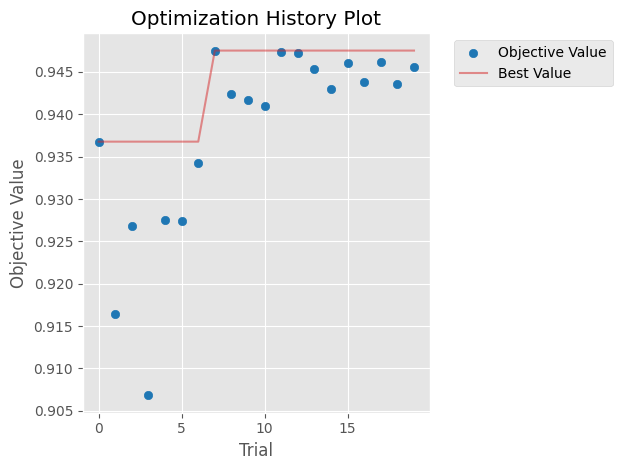

In [16]:
import optuna.visualization.matplotlib as optuna_mpl
import matplotlib.pyplot as plt

optuna_mpl.plot_optimization_history(study)
plt.show()

The Optuna optimization converged on the 6th out of 20 attempts, confirming that the chosen search space was sufficiently targeted.

In [17]:
print("Meilleurs paramètres :", study.best_params)
print("Meilleure AUC        :", study.best_value)

Meilleurs paramètres : {'max_depth': 8, 'learning_rate': 0.11961118725347385, 'subsample': 0.9720661844731725, 'colsample_bytree': 0.5027122497475527, 'min_child_weight': 4, 'reg_alpha': 5.10260525172356, 'reg_lambda': 9.336958171919783}
Meilleure AUC        : 0.9475166421614167


In [21]:
best_params = study.best_params.copy()

best_params.update({
    'n_estimators':          1000,
    'scale_pos_weight':      len(y[y==0]) / len(y[y==1]),
    'tree_method':           'hist',
    'eval_metric':           'auc',
    'early_stopping_rounds': 50,
    'random_state':          42,
    'n_jobs':                -1,
})

print("Final parameters used :")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Final parameters used :
  max_depth: 8
  learning_rate: 0.11961118725347385
  subsample: 0.9720661844731725
  colsample_bytree: 0.5027122497475527
  min_child_weight: 4
  reg_alpha: 5.10260525172356
  reg_lambda: 9.336958171919783
  n_estimators: 1000
  scale_pos_weight: 27.579586700866283
  tree_method: hist
  eval_metric: auc
  early_stopping_rounds: 50
  random_state: 42
  n_jobs: -1


In [ ]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros(len(X))
scores = []

for fold, (idx_train, idx_val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

    model = XGBClassifier(**best_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    oof[idx_val] = model.predict_proba(X_val)[:, 1]
    scores.append(roc_auc_score(y_val, oof[idx_val]))
    print(f"Fold {fold+1} AUC : {scores[-1]:.4f}")

print(f"\nAUC moyenne    : {np.mean(scores):.4f}")
print(f"AUC OOF totale : {roc_auc_score(y, oof):.4f}")

0 colonnes str restantes : []
[0]	validation_0-auc:0.84542
[100]	validation_0-auc:0.91224
[200]	validation_0-auc:0.92931


KeyboardInterrupt: 

In [22]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
scores = []

for fold, (idx_train, idx_val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

    model = XGBClassifier(**best_params)

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

    oof[idx_val] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

    scores.append(roc_auc_score(y_val, oof[idx_val]))
    print(f"Fold {fold+1} AUC : {scores[-1]:.4f}")

print(f"MeanAUC: {np.mean(scores):.4f}")
print(f"AUC OOF totale : {roc_auc_score(y, oof):.4f}")

[0]	validation_0-auc:0.86485
[100]	validation_0-auc:0.94791
[200]	validation_0-auc:0.95813
[300]	validation_0-auc:0.96301
[400]	validation_0-auc:0.96539
[500]	validation_0-auc:0.96687
[600]	validation_0-auc:0.96808
[700]	validation_0-auc:0.96905
[800]	validation_0-auc:0.96954
[900]	validation_0-auc:0.97023
[999]	validation_0-auc:0.97063
Fold 1 AUC : 0.9706
[0]	validation_0-auc:0.85907
[100]	validation_0-auc:0.94850
[200]	validation_0-auc:0.95926
[300]	validation_0-auc:0.96361
[400]	validation_0-auc:0.96602
[500]	validation_0-auc:0.96775
[600]	validation_0-auc:0.96910
[700]	validation_0-auc:0.96985
[800]	validation_0-auc:0.97068
[900]	validation_0-auc:0.97121
[999]	validation_0-auc:0.97169
Fold 2 AUC : 0.9717
[0]	validation_0-auc:0.85798
[100]	validation_0-auc:0.94633
[200]	validation_0-auc:0.95714
[300]	validation_0-auc:0.96219
[400]	validation_0-auc:0.96496
[500]	validation_0-auc:0.96691
[600]	validation_0-auc:0.96817
[700]	validation_0-auc:0.96908
[800]	validation_0-auc:0.96994
[900]

In [23]:
submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)